#  Simulación Monte Carlo WC2026

El objetivo es:
> Usar las probabilidades del modelo para **simular el torneo completo 10,000 veces**
> y determinar qué selección tiene más probabilidad de ser campeona del WC2026.

## ¿Por qué Monte Carlo y no predecir directo?

El modelo predice la probabilidad de cada resultado partido a partido.
No predice el campeón directamente — eso sería caer en el problema de
desbalance de clases .

Con Monte Carlo repetimos el torneo miles de veces y contamos frecuencias:
Torneo × 10,000 simulaciones
→ Argentina campeón en 2,847 simulaciones = 28.47% de probabilidad
→ España campeón en 2,103 simulaciones    = 21.03% de probabilidad

El error estadístico con 10,000 iteraciones es aproximadamente ±0.5%,
suficientemente preciso para un Top-5 confiable.

## 4.1 Cargar modelo y datos WC2026

Cargar en memoria todo lo construido en NB03:

- `xgb_model.pkl` → modelo XGBoost que predice probabilidades H/D/A
- `label_encoder.pkl` → traduce 0=A, 1=D, 2=H
- `elo_ratings.csv` → ELO final de cada selección
- `ranking_clean.csv` → ranking FIFA y puntos (snapshot jun-2024)
- `transfermarkt_clean.csv` → valor de plantilla en millones €
- `worldbank_clean.csv` → PIB per cápita por país
- `wc2026_players_top_league.csv` → jugadores en ligas top 5
- `wc2026_grupos.csv` → los 72 partidos de la fase de grupos

In [1]:
# ── Imports ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import pickle
import json
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Rutas del proyecto ────────────────────────────────────────────
BASE_DIR  = Path('..')
DATA_RAW  = BASE_DIR / 'data' / 'raw'
DATA_PROC = BASE_DIR / 'data' / 'processed'
REPORTS   = BASE_DIR / 'reports'
REPORTS.mkdir(parents=True, exist_ok=True)

# ── Constantes del torneo ─────────────────────────────────────────
FEATURE_COLS = [
    'elo_home', 'elo_away', 'elo_diff',
    'fifa_rank_home', 'fifa_rank_away', 'fifa_points_diff',
    'squad_value_home', 'squad_value_away', 'squad_value_diff',
    'players_top_lge_home', 'players_top_lge_away',
    'gdp_per_capita_home', 'gdp_per_capita_away',
    'is_neutral', 'tournament_weight'
]

# En fase eliminatoria siempre cancha neutral, peso máximo
IS_NEUTRAL_KO        = 1
TOURNAMENT_WEIGHT_KO = 1.0
N_SIMULATIONS        = 10_000

# Índices del LabelEncoder: A=0, D=1, H=2
IDX_A, IDX_D, IDX_H = 0, 1, 2

print("✅ Imports y configuración listos")
print(f"   FEATURE_COLS  : {len(FEATURE_COLS)} features")
print(f"   N_SIMULATIONS : {N_SIMULATIONS:,}")
print(f"   REPORTS dir   : {REPORTS}")

✅ Imports y configuración listos
   FEATURE_COLS  : 15 features
   N_SIMULATIONS : 10,000
   REPORTS dir   : ../reports


In [2]:
# ── Cargar modelo XGBoost ─────────────────────────────────────────
with open(DATA_PROC / 'xgb_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

print("✅ Modelo XGBoost cargado")
print(f"   N estimadores : {xgb_model.n_estimators}")
print(f"   Max depth     : {xgb_model.max_depth}")

# ── Reconstruir LabelEncoder ──────────────────────────────────────
# El pkl fue guardado con versión incompatible de sklearn
# Lo reconstruimos directamente — el encoding es conocido: A=0, D=1, H=2
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(['A', 'D', 'H'])

print()
print("✅ LabelEncoder reconstruido")
print(f"   Clases : {le.classes_}  →  A=0, D=1, H=2")
print(f"   Verify : A={le.transform(['A'])[0]}, "
      f"D={le.transform(['D'])[0]}, "
      f"H={le.transform(['H'])[0]}")

✅ Modelo XGBoost cargado
   N estimadores : 300
   Max depth     : 4

✅ LabelEncoder reconstruido
   Clases : ['A' 'D' 'H']  →  A=0, D=1, H=2
   Verify : A=0, D=1, H=2


In [3]:
# ── Cargar datasets de features ───────────────────────────────────

# ELO ratings finales (generados en NB03)
elo_df   = pd.read_csv(DATA_PROC / 'elo_ratings.csv')
elo_map  = dict(zip(elo_df['team'], elo_df['elo_rating']))

# Ranking FIFA (snapshot jun-2024)
rank_df  = pd.read_csv(DATA_PROC / 'ranking_clean.csv')
rank_map = dict(zip(rank_df['team'], rank_df['fifa_rank']))
pts_map  = dict(zip(rank_df['team'], rank_df['fifa_points']))

# Valor de plantilla Transfermarkt
# columna real: squad_value_eur (en euros, no millones)
tm_df     = pd.read_csv(DATA_PROC / 'transfermarkt_clean.csv')
squad_map = dict(zip(tm_df['team'], tm_df['squad_value_eur']))

# PIB per cápita World Bank
wb_df   = pd.read_csv(DATA_PROC / 'worldbank_clean.csv')
gdp_map = dict(zip(wb_df['team'], wb_df['gdp_per_capita']))

# Jugadores en ligas top 5
# columna real: players_top_league (no players_top_lge)
top_df     = pd.read_csv(DATA_PROC / 'wc2026_players_top_league.csv')
toplge_map = dict(zip(top_df['team'], top_df['players_top_league']))

# 72 partidos fase de grupos WC2026
grupos_df = pd.read_csv(DATA_PROC / 'wc2026_grupos.csv')

print("✅ Datasets cargados:")
print(f"   ELO ratings       : {len(elo_map)} equipos")
print(f"   Ranking FIFA      : {len(rank_map)} equipos")
print(f"   Valores plantilla : {len(squad_map)} equipos")
print(f"   PIB per cápita    : {len(gdp_map)} equipos")
print(f"   Jugadores top lge : {len(toplge_map)} equipos")
print(f"   Partidos grupos   : {len(grupos_df)} partidos")

✅ Datasets cargados:
   ELO ratings       : 336 equipos
   Ranking FIFA      : 229 equipos
   Valores plantilla : 48 equipos
   PIB per cápita    : 54 equipos
   Jugadores top lge : 48 equipos
   Partidos grupos   : 72 partidos


In [4]:
# ── Calcular medianas globales ────────────────────────────────────
# Se usan como fallback para equipos sin datos en alguna feature
# Esto resuelve el problema de equipos debutantes (criterio 4e)

ELO_MEDIAN    = np.median(list(elo_map.values()))
RANK_MEDIAN   = np.median(list(rank_map.values()))
PTS_MEDIAN    = np.median(list(pts_map.values()))
SQUAD_MEDIAN  = np.median(list(squad_map.values()))
GDP_MEDIAN    = np.median(list(gdp_map.values()))
TOPLGE_MEDIAN = np.median(list(toplge_map.values()))

print("📊 Medianas globales (fallback para equipos sin datos):")
print(f"   ELO rating      : {ELO_MEDIAN:.0f}")
print(f"   FIFA rank       : {RANK_MEDIAN:.0f}")
print(f"   FIFA points     : {PTS_MEDIAN:.0f}")
print(f"   Squad value     : {SQUAD_MEDIAN/1e6:.1f} M€")
print(f"   GDP per capita  : {GDP_MEDIAN:.0f} USD")
print(f"   Players top lge : {TOPLGE_MEDIAN:.0f}")

# ── Verificar cobertura para los 48 equipos WC2026 ────────────────
equipos_wc2026 = sorted(list(set(
    grupos_df['home_team'].tolist() + grupos_df['away_team'].tolist()
)))

print(f"\n📋 Equipos WC2026 detectados desde wc2026_grupos.csv: {len(equipos_wc2026)}")
print()

# Revisar qué equipos tienen datos faltantes
print("🔍 Cobertura de features por equipo:")
faltantes_log = []
for equipo in equipos_wc2026:
    faltantes = []
    if equipo not in elo_map:    faltantes.append('ELO')
    if equipo not in rank_map:   faltantes.append('FIFA_rank')
    if equipo not in squad_map:  faltantes.append('squad_value')
    if equipo not in gdp_map:    faltantes.append('gdp')
    if equipo not in toplge_map: faltantes.append('top_lge')
    if faltantes:
        print(f"   ⚠️  {equipo:<30s} falta: {faltantes}")
        faltantes_log.append({'equipo': equipo, 'faltantes': faltantes})

if not faltantes_log:
    print("   ✅ Todos los equipos tienen datos completos")

print(f"\n✅ Sección 4.1 completada")
print(f"   Equipos con datos incompletos : {len(faltantes_log)}")
print(f"   Serán tratados con medianas globales")

📊 Medianas globales (fallback para equipos sin datos):
   ELO rating      : 1490
   FIFA rank       : 108
   FIFA points     : 1178
   Squad value     : 285.7 M€
   GDP per capita  : 23063 USD
   Players top lge : 12

📋 Equipos WC2026 detectados desde wc2026_grupos.csv: 48

🔍 Cobertura de features por equipo:
   ✅ Todos los equipos tienen datos completos

✅ Sección 4.1 completada
   Equipos con datos incompletos : 0
   Serán tratados con medianas globales


## 4.2 Función `build_features()`

Esta es la función central del notebook. Dado cualquier partido
(equipo_A vs equipo_B), construye el vector de 15 features que
el modelo XGBoost necesita para predecir probabilidades.

En La copa del mundo 2026 los 3 anfitriones son USA, Canada y Mexico.
Cuando uno de ellos juega en su país → is_neutral = 0.
En todas las demás fases → is_neutral = 1.

In [5]:
# ── Función auxiliar con fallback a medianas ──────────────────────
def get_feature(mapping, team, default):
    """
    Obtiene valor del diccionario de features.
    Si el equipo no existe devuelve la mediana global.
    Resuelve el problema de equipos debutantes (criterio 4e).
    """
    return mapping.get(team, default)


# ── Función principal build_features ─────────────────────────────
def build_features(home_team, away_team, is_neutral=0, tournament_weight=1.0):
    """
    Construye el vector de 15 features para un partido.

    Parámetros:
    -----------
    home_team         : str   → equipo local
    away_team         : str   → equipo visitante
    is_neutral        : int   → 1 si cancha neutral
    tournament_weight : float → 1.0 para World Cup

    Retorna:
    --------
    np.array shape (1, 15) listo para predict_proba()
    """
    # ── Features individuales con fallback a medianas ─────────────
    elo_h  = get_feature(elo_map,    home_team, ELO_MEDIAN)
    elo_a  = get_feature(elo_map,    away_team, ELO_MEDIAN)
    rank_h = get_feature(rank_map,   home_team, RANK_MEDIAN)
    rank_a = get_feature(rank_map,   away_team, RANK_MEDIAN)
    pts_h  = get_feature(pts_map,    home_team, PTS_MEDIAN)
    pts_a  = get_feature(pts_map,    away_team, PTS_MEDIAN)
    sqd_h  = get_feature(squad_map,  home_team, SQUAD_MEDIAN)
    sqd_a  = get_feature(squad_map,  away_team, SQUAD_MEDIAN)
    gdp_h  = get_feature(gdp_map,    home_team, GDP_MEDIAN)
    gdp_a  = get_feature(gdp_map,    away_team, GDP_MEDIAN)
    top_h  = get_feature(toplge_map, home_team, TOPLGE_MEDIAN)
    top_a  = get_feature(toplge_map, away_team, TOPLGE_MEDIAN)

    # ── Vector en el mismo orden que FEATURE_COLS ─────────────────
    X = np.array([[
        elo_h,                  # elo_home
        elo_a,                  # elo_away
        elo_h - elo_a,          # elo_diff
        rank_h,                 # fifa_rank_home
        rank_a,                 # fifa_rank_away
        pts_h - pts_a,          # fifa_points_diff
        sqd_h,                  # squad_value_home
        sqd_a,                  # squad_value_away
        sqd_h - sqd_a,          # squad_value_diff
        top_h,                  # players_top_lge_home
        top_a,                  # players_top_lge_away
        gdp_h,                  # gdp_per_capita_home
        gdp_a,                  # gdp_per_capita_away
        is_neutral,             # is_neutral
        tournament_weight       # tournament_weight
    ]])

    return X


# ── Test rápido ───────────────────────────────────────────────────
X_test = build_features('Argentina', 'Mexico', is_neutral=0, tournament_weight=1.0)
probs  = xgb_model.predict_proba(X_test)[0]   # [P(A), P(D), P(H)]

print("🧪 Test: Argentina (local) vs México")
print(f"   Shape features   : {X_test.shape}  ← debe ser (1, 15)")
print(f"   P(México gana)   : {probs[IDX_A]:.3f}")
print(f"   P(Empate)        : {probs[IDX_D]:.3f}")
print(f"   P(Argentina)     : {probs[IDX_H]:.3f}")
print(f"   Suma probabilidades: {probs.sum():.4f}  ← debe ser 1.0")
print()
print("✅ Sección 4.2 completada")

🧪 Test: Argentina (local) vs México
   Shape features   : (1, 15)  ← debe ser (1, 15)
   P(México gana)   : 0.251
   P(Empate)        : 0.158
   P(Argentina)     : 0.591
   Suma probabilidades: 1.0000  ← debe ser 1.0

✅ Sección 4.2 completada


## 4.3 Función `simulate_match()`

Con las probabilidades del modelo necesitamos decidir quién gana
cada partido. Usamos un **sorteo ponderado**:
probs = [P(A)=0.25, P(D)=0.16, P(H)=0.59]
resultado = np.random.choice(['A', 'D', 'H'], p=probs)

### Regla especial en eliminatorias

En rondas eliminatorias no puede haber empate. Si el sorteo
cae en 'D' hacemos un desempate 50/50 que simula penales:
D  →  np.random.choice([home, away], p=[0.5, 0.5])

In [6]:
# ── Función simulate_match ────────────────────────────────────────
def simulate_match(home_team, away_team, is_neutral=0,
                   tournament_weight=1.0, allow_draw=True):
    """
    Simula un partido usando probabilidades del modelo XGBoost.

    Parámetros:
    -----------
    home_team         : str   → equipo local
    away_team         : str   → equipo visitante
    is_neutral        : int   → 1 si cancha neutral
    tournament_weight : float → 1.0 para World Cup
    allow_draw        : bool  → False en rondas eliminatorias

    Retorna:
    --------
    dict con winner, result, prob_h, prob_d, prob_a
    """
    # ── Obtener probabilidades del modelo ─────────────────────────
    X     = build_features(home_team, away_team, is_neutral, tournament_weight)
    probs = xgb_model.predict_proba(X)[0]   # [P(A), P(D), P(H)]

    p_h = probs[IDX_H]
    p_d = probs[IDX_D]
    p_a = probs[IDX_A]

    # ── Normalizar para evitar error de redondeo flotante ─────────
    # numpy exige que sumen exactamente 1.0
    p = np.array([p_h, p_d, p_a], dtype=np.float64)
    p = p / p.sum()

    # ── Sorteo ponderado: dado cargado por probabilidades ─────────
    result = np.random.choice(['H', 'D', 'A'], p=p)

    # ── Determinar ganador ────────────────────────────────────────
    if result == 'H':
        winner = home_team
    elif result == 'A':
        winner = away_team
    else:
        if allow_draw:
            winner = None              # empate válido en grupos
        else:
            # Eliminatorias: desempate 50/50 simula penales
            winner = np.random.choice([home_team, away_team])
            result = 'H' if winner == home_team else 'A'

    return {
        'winner': winner,
        'result': result,
        'prob_h': p_h,
        'prob_d': p_d,
        'prob_a': p_a
    }


# ── Test 1: partido con empate permitido (fase grupos) ────────────
print("🧪 Test 1: Argentina vs México — 10 simulaciones (grupos):")
for i in range(10):
    r = simulate_match('Argentina', 'Mexico', is_neutral=1)
    ganador = r['winner'] if r['winner'] else 'EMPATE'
    print(f"   Sim {i+1:2d}: {r['result']}  →  {ganador}")

# ── Test 2: eliminatoria sin empate ──────────────────────────────
print()
print("🧪 Test 2: España vs Brasil — 5 simulaciones (eliminatoria):")
for i in range(5):
    r = simulate_match('Spain', 'Brazil', is_neutral=1, allow_draw=False)
    print(f"   Sim {i+1}: {r['result']}  →  ganó {r['winner']}")

print()
print("✅ Sección 4.3 completada")

🧪 Test 1: Argentina vs México — 10 simulaciones (grupos):
   Sim  1: H  →  Argentina
   Sim  2: A  →  Mexico
   Sim  3: D  →  EMPATE
   Sim  4: D  →  EMPATE
   Sim  5: H  →  Argentina
   Sim  6: H  →  Argentina
   Sim  7: H  →  Argentina
   Sim  8: A  →  Mexico
   Sim  9: D  →  EMPATE
   Sim 10: D  →  EMPATE

🧪 Test 2: España vs Brasil — 5 simulaciones (eliminatoria):
   Sim 1: H  →  ganó Spain
   Sim 2: A  →  ganó Brazil
   Sim 3: A  →  ganó Brazil
   Sim 4: H  →  ganó Spain
   Sim 5: H  →  ganó Spain

✅ Sección 4.3 completada


## 4.4 Estructura oficial del torneo WC2026

Antes de simular necesitamos tres cosas:
1. Recargar `tournament_structure.py` con el bracket oficial
2. Generar la matriz de 495 combinaciones del Anexo C FIFA
3. Definir el diccionario de normalización de nombres

### ¿Por qué la matriz de 495 combinaciones?
En WC2026 hay 12 grupos → 12 terceros → solo 8 clasifican.
Dependiendo de QUÉ 8 grupos aporten el tercero, FIFA tiene
predefinido contra quién juega cada uno en dieciseisavos.


C(12,8) = 495 combinaciones posibles


Cada combinación tiene una asignación exacta:
- Clave  : grupos ordenados → "ABCDEFGI"
- Valor  : lista de 8 rivales → ["3C","3F","3I","3A","3E","3D","3G","3B"]
- Orden  : siempre [1A, 1B, 1D, 1E, 1G, 1I, 1K, 1L]

Los 4 líderes que NUNCA juegan contra terceros:
- 1C vs 2F  (fijo)
- 1F vs 2C  (fijo)
- 1H vs 2J  (fijo)
- 1J vs 2H  (fijo)

In [7]:
# ── Recargar tournament_structure.py ─────────────────────────────
import sys

# Agregar src/ al path usando BASE_DIR ya definido
SRC_DIR = BASE_DIR / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

if 'tournament_structure' in sys.modules:
    del sys.modules['tournament_structure']

from tournament_structure import (
    GRUPOS,
    FIXTURES_GRUPOS,
    REGLAS_CLASIFICACION,
    FASES_ELIMINATORIAS,
    PARTIDOS_POR_FASE,
    CRUCES_FIJOS,
    ORDEN_LIDERES_TERCEROS,
    PARTIDO_POR_LIDER,
    asignar_terceros_a_cruces,
)

print("✅ tournament_structure.py recargado")
print()
print(f"   Grupos              : {len(GRUPOS)}")
print(f"   Cruces fijos        : {len(CRUCES_FIJOS)}")
print(f"   Líderes con terceros: {len(ORDEN_LIDERES_TERCEROS)}")
print(f"   Total partidos      : {PARTIDOS_POR_FASE['TOTAL']}")
print()

# ── Verificar bracket ─────────────────────────────────────────────
partidos_fijos    = set(CRUCES_FIJOS.keys())
partidos_terceros = set(PARTIDO_POR_LIDER.values())
superposicion     = partidos_fijos & partidos_terceros
todos_definidos   = partidos_fijos | partidos_terceros
todos_esperados   = set(range(73, 89))
faltantes         = todos_esperados - todos_definidos

print("🔍 Verificando bracket:")
print(f"   Cruces fijos    (8) : {sorted(partidos_fijos)}")
print(f"   Cruces terceros (8) : {sorted(partidos_terceros)}")
print(f"   Total definidos     : {len(todos_definidos)}  ← debe ser 16")

if superposicion:
    print(f"   ❌ Superposición    : {sorted(superposicion)}")
else:
    print(f"   ✅ Sin superposición")

if faltantes:
    print(f"   ❌ Faltantes        : {sorted(faltantes)}")
else:
    print(f"   ✅ Ningún partido faltante")

print()
print(f"   Partidos completos  : {sorted(todos_definidos)}")

✅ tournament_structure.py recargado

   Grupos              : 12
   Cruces fijos        : 8
   Líderes con terceros: 8
   Total partidos      : 104

🔍 Verificando bracket:
   Cruces fijos    (8) : [73, 74, 75, 78, 83, 84, 86, 88]
   Cruces terceros (8) : [76, 77, 79, 80, 81, 82, 85, 87]
   Total definidos     : 16  ← debe ser 16
   ✅ Sin superposición
   ✅ Ningún partido faltante

   Partidos completos  : [73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88]


In [8]:
# ── Generar matriz oficial Anexo C FIFA ───────────────────────────
# C(12,8) = 495 combinaciones posibles de terceros clasificados
# Cada combinación define contra quién juega cada líder

import itertools

# Restricciones oficiales FIFA
# Cada líder solo puede enfrentarse a terceros de estos grupos
prioridades = {
    '1A': ['C', 'E', 'F', 'H', 'I'],
    '1B': ['E', 'F', 'G', 'I', 'J'],
    '1D': ['B', 'E', 'F', 'I', 'J'],
    '1E': ['A', 'B', 'C', 'D', 'F'],
    '1G': ['A', 'E', 'H', 'I', 'J'],
    '1I': ['C', 'D', 'F', 'G', 'H'],
    '1K': ['D', 'E', 'I', 'J', 'L'],
    '1L': ['E', 'H', 'I', 'J', 'K'],
}

grupos_todos   = ['A','B','C','D','E','F','G','H','I','J','K','L']
matriz_completa = {}

# ── Generar las 495 combinaciones ────────────────────────────────
for comb in itertools.combinations(grupos_todos, 8):
    clave       = "".join(comb)   # ej: "ABCDEFGH"
    asignacion  = {}
    disponibles = list(comb)

    for lider in ORDEN_LIDERES_TERCEROS:
        # Buscar primer grupo disponible dentro del pool del líder
        opciones = [g for g in prioridades[lider] if g in disponibles]
        if opciones:
            seleccionada = opciones[0]
        else:
            # Fallback: tomar cualquier disponible
            seleccionada = disponibles[0]
        asignacion[lider] = f"3{seleccionada}"
        disponibles.remove(seleccionada)

    # Guardar como lista ordenada por ORDEN_LIDERES_TERCEROS
    matriz_completa[clave] = [asignacion[l] for l in ORDEN_LIDERES_TERCEROS]

# ── Guardar en data/processed/ ────────────────────────────────────
output_path = DATA_PROC / 'matriz_mundial_495.json'
with open(output_path, 'w') as f:
    json.dump(matriz_completa, f, indent=2)

print(f"✅ Matriz generada: {len(matriz_completa)} combinaciones")
print(f"💾 Guardada en: {output_path}")
print()

# ── Verificar ejemplos ────────────────────────────────────────────
ejemplos = ["ABCDEFGH", "ABCDEFGI", "BCDEFGIJ"]
for clave_test in ejemplos:
    if clave_test in matriz_completa:
        resultado = matriz_completa[clave_test]
        print(f"🧪 Clave '{clave_test}':")
        for i, lider in enumerate(ORDEN_LIDERES_TERCEROS):
            print(f"   {lider} vs {resultado[i]}")
        print()

✅ Matriz generada: 495 combinaciones
💾 Guardada en: ../data/processed/matriz_mundial_495.json

🧪 Clave 'ABCDEFGH':
   1A vs 3C
   1B vs 3E
   1D vs 3B
   1E vs 3A
   1G vs 3H
   1I vs 3D
   1K vs 3F
   1L vs 3G

🧪 Clave 'ABCDEFGI':
   1A vs 3C
   1B vs 3E
   1D vs 3B
   1E vs 3A
   1G vs 3I
   1I vs 3D
   1K vs 3F
   1L vs 3G

🧪 Clave 'BCDEFGIJ':
   1A vs 3C
   1B vs 3E
   1D vs 3B
   1E vs 3D
   1G vs 3I
   1I vs 3F
   1K vs 3J
   1L vs 3G



In [9]:
# ── Diccionario de normalización de nombres ───────────────────────
# Mapea nombres de tournament_structure.py → nombres en los CSVs

NOMBRE_MAP = {
    'Bosnia-Herzegovina' : 'Bosnia and Herzegovina',
    'United States'      : 'USA',
    'Turkiye'            : 'Turkey',
}

# Anfitriones con ventaja de localía
# Nombres TAL COMO aparecen en FIXTURES_GRUPOS
HOSTS = {'United States', 'Canada', 'Mexico'}

def normalize(team):
    """
    Normaliza nombre de equipo al estándar de los CSVs.
    Si no está en el mapa devuelve el nombre original.
    """
    return NOMBRE_MAP.get(team, team)

# ── Verificar normalización ───────────────────────────────────────
print("✅ Normalización de nombres:")
for original, normalizado in NOMBRE_MAP.items():
    en_elo   = normalizado in elo_map
    en_rank  = normalizado in rank_map
    estado   = "✅" if (en_elo and en_rank) else "❌"
    print(f"   {estado} {original:<25s} → {normalizado}")

print()
print(f"✅ Hosts (nombres originales): {HOSTS}")
print()

# ── Verificar cobertura completa de los 48 equipos ───────────────
todos_equipos = []
for teams in GRUPOS.values():
    todos_equipos.extend(teams)

sin_datos = []
for equipo in todos_equipos:
    eq_norm   = normalize(equipo)
    faltantes = []
    if eq_norm not in elo_map:    faltantes.append('ELO')
    if eq_norm not in rank_map:   faltantes.append('rank')
    if eq_norm not in squad_map:  faltantes.append('squad')
    if eq_norm not in gdp_map:    faltantes.append('gdp')
    if eq_norm not in toplge_map: faltantes.append('top_lge')
    if faltantes:
        sin_datos.append(equipo)
        print(f"   ⚠️  {equipo:<25s} falta: {faltantes}")

if not sin_datos:
    print("✅ Los 48 equipos tienen cobertura completa")

print()
print("✅ Sección 4.4 — estructura del torneo lista")

✅ Normalización de nombres:
   ✅ Bosnia-Herzegovina        → Bosnia and Herzegovina
   ✅ United States             → USA
   ✅ Turkiye                   → Turkey

✅ Hosts (nombres originales): {'Canada', 'United States', 'Mexico'}

✅ Los 48 equipos tienen cobertura completa

✅ Sección 4.4 — estructura del torneo lista


## 4.5 Simulación fase de grupos

### Sistema de puntos
- Victoria : 3 puntos
- Empate   : 1 punto cada equipo
- Derrota  : 0 puntos

### Clasificados
- 1ro y 2do de cada grupo → 24 equipos directos
- 8 mejores terceros de 12 → 8 equipos adicionales
- Total: 32 equipos a dieciseisavos

### Criterios de desempate entre terceros (orden oficial FIFA)
1. Puntos
2. Diferencia de goles
3. Goles marcados
4. Fair play (tarjetas)
5. Ranking FIFA
6. Sorteo

### Lo que retorna esta función
Además de los 32 clasificados, necesitamos saber
**de qué grupo viene cada tercero** para poder
consultar la matriz de 495 combinaciones en 4.6.

In [10]:
# ── Función simulate_group_stage ──────────────────────────────────
def simulate_group_stage():
    """
    Simula los 72 partidos de la fase de grupos WC2026.

    Retorna:
    --------
    qualified_1ros  : list de 12 equipos (1ros de grupo)
    qualified_2dos  : list de 12 equipos (2dos de grupo)
    best_thirds     : list de 8 equipos  (mejores terceros)
    grupos_terceros : list de 8 letras   (grupos de origen de los terceros)
    standings       : dict con tabla de posiciones completa
    """
    # ── Inicializar tabla de posiciones ───────────────────────────
    standings = {}
    for grupo, teams in GRUPOS.items():
        for team in teams:
            standings[team] = {
                'group'  : grupo,
                'pts'    : 0,
                'gf'     : 0,
                'ga'     : 0,
                'gd'     : 0,
                'wins'   : 0,
                'draws'  : 0,
                'losses' : 0,
            }

    # ── Simular los 72 partidos ───────────────────────────────────
    for grupo, fixtures in FIXTURES_GRUPOS.items():
        for (home, away) in fixtures:

            # is_neutral: 0 si un anfitrión juega en casa
            is_neutral = 0 if (home in HOSTS or away in HOSTS) else 1

            # Simular con nombres normalizados para features
            match = simulate_match(
                normalize(home), normalize(away),
                is_neutral=is_neutral,
                tournament_weight=1.0,
                allow_draw=True
            )

            # Simular goles con distribución Poisson
            lambda_h = 1.3 + 0.5 * (match['prob_h'] - 0.33)
            lambda_a = 1.3 + 0.5 * (match['prob_a'] - 0.33)
            gf_h = max(0, np.random.poisson(lambda_h))
            gf_a = max(0, np.random.poisson(lambda_a))

            # Asegurar consistencia resultado vs goles
            if match['result'] == 'H' and gf_h <= gf_a:
                gf_h = gf_a + 1
            elif match['result'] == 'A' and gf_a <= gf_h:
                gf_a = gf_h + 1
            elif match['result'] == 'D':
                gf_a = gf_h

            # Actualizar tabla con nombres originales
            standings[home]['gf'] += gf_h
            standings[home]['ga'] += gf_a
            standings[away]['gf'] += gf_a
            standings[away]['ga'] += gf_h

            if match['result'] == 'H':
                standings[home]['pts']    += 3
                standings[home]['wins']   += 1
                standings[away]['losses'] += 1
            elif match['result'] == 'A':
                standings[away]['pts']    += 3
                standings[away]['wins']   += 1
                standings[home]['losses'] += 1
            else:
                standings[home]['pts']   += 1
                standings[away]['pts']   += 1
                standings[home]['draws'] += 1
                standings[away]['draws'] += 1

    # Calcular diferencia de goles
    for team in standings:
        standings[team]['gd'] = standings[team]['gf'] - standings[team]['ga']

    # ── Clasificar equipos por grupo ─────────────────────────────
    qualified_1ros = []
    qualified_2dos = []
    all_thirds     = []

    for grupo, teams in GRUPOS.items():
        sorted_teams = sorted(
            teams,
            key=lambda t: (
                standings[t]['pts'],
                standings[t]['gd'],
                standings[t]['gf'],
            ),
            reverse=True
        )
        qualified_1ros.append(sorted_teams[0])
        qualified_2dos.append(sorted_teams[1])
        all_thirds.append({
            'team'  : sorted_teams[2],
            'group' : grupo,
            'pts'   : standings[sorted_teams[2]]['pts'],
            'gd'    : standings[sorted_teams[2]]['gd'],
            'gf'    : standings[sorted_teams[2]]['gf'],
            'rank'  : rank_map.get(normalize(sorted_teams[2]), RANK_MEDIAN),
        })

    # ── Seleccionar 8 mejores terceros ────────────────────────────
    # Criterios oficiales FIFA en orden:
    # puntos → dif_goles → goles_marcados → ranking_fifa
    thirds_sorted = sorted(
        all_thirds,
        key=lambda x: (x['pts'], x['gd'], x['gf'], -x['rank']),
        reverse=True
    )
    best_thirds    = [t['team']  for t in thirds_sorted[:8]]
    grupos_terceros = [t['group'] for t in thirds_sorted[:8]]

    return qualified_1ros, qualified_2dos, best_thirds, grupos_terceros, standings


# ── Test: simular fase de grupos una vez ──────────────────────────
print("🧪 Test: simulando fase de grupos...")
q1, q2, q3, g3, st = simulate_group_stage()

print(f"✅ Clasificados:")
print(f"   1ros de grupo (12) : {q1}")
print(f"   2dos de grupo (12) : {q2}")
print(f"   Mejores 3ros  ( 8) : {q3}")
print(f"   Grupos terceros    : {g3}")
print()
print("📋 Tabla Grupo J (Argentina):")
for team, s in sorted(
        {t: st[t] for t in GRUPOS['J']}.items(),
        key=lambda x: (-x[1]['pts'], -x[1]['gd'], -x[1]['gf'])):
    print(f"   {team:<25s} Pts:{s['pts']}  "
          f"GD:{s['gd']:+d}  GF:{s['gf']}")
print()
print("✅ Sección 4.5 completada")

🧪 Test: simulando fase de grupos...
✅ Clasificados:
   1ros de grupo (12) : ['Mexico', 'Switzerland', 'Morocco', 'United States', 'Ecuador', 'Japan', 'Iran', 'Spain', 'Senegal', 'Argentina', 'Colombia', 'Croatia']
   2dos de grupo (12) : ['South Korea', 'Bosnia-Herzegovina', 'Brazil', 'Australia', 'Germany', 'Netherlands', 'Belgium', 'Uruguay', 'France', 'Austria', 'Portugal', 'Ghana']
   Mejores 3ros  ( 8) : ['Canada', 'Ivory Coast', 'Norway', 'Sweden', 'England', 'Saudi Arabia', 'Jordan', 'Uzbekistan']
   Grupos terceros    : ['B', 'E', 'I', 'F', 'L', 'H', 'J', 'K']

📋 Tabla Grupo J (Argentina):
   Argentina                 Pts:9  GD:+6  GF:10
   Austria                   Pts:4  GD:+0  GF:4
   Jordan                    Pts:3  GD:-1  GF:3
   Algeria                   Pts:1  GD:-5  GF:1

✅ Sección 4.5 completada


## 4.6 Simulación fase eliminatoria

Con 32 equipos clasificados armamos el bracket oficial
usando los cruces fijos y la matriz de 495 combinaciones.

### Flujo del bracket

simulate_group_stage()
↓
1ros(12) + 2dos(12) + mejores_3ros(8) + grupos_3ros(8)
↓
asignar_terceros_a_cruces(grupos_3ros) → matriz 495
↓
Bracket completo de dieciseisavos (16 partidos)
↓
Octavos → Cuartos → Semis → Final

### Reglas fase eliminatoria
- Siempre `is_neutral = 1` — estadios neutrales
- Siempre `allow_draw = False` — debe haber ganador
- Empate en sorteo → desempate 50/50 (simula penales)

### Estructura del bracket por ramas

Rama izquierda          Rama derecha
──────────────          ─────────────
P73, P74, P75, P76      P83, P84, P85, P86
P77, P78, P79, P80      P87, P88, ...
↓                       ↓
Octavos izq             Octavos der
↓                       ↓
Semis  ←────────────→  Semis
↓
Final

In [11]:
# ── Función auxiliar: simular un partido eliminatorio ────────────
def sim_ko_match(home_orig, away_orig):
    """
    Simula un partido eliminatorio entre dos equipos.
    Usa nombres originales del fixture, normaliza internamente.
    Retorna el ganador en nombre original.
    """
    match = simulate_match(
        normalize(home_orig), normalize(away_orig),
        is_neutral=IS_NEUTRAL_KO,
        tournament_weight=TOURNAMENT_WEIGHT_KO,
        allow_draw=False
    )
    if match['winner'] == normalize(home_orig):
        return home_orig
    else:
        return away_orig


# ── Función principal simulate_knockout_stage ────────────────────
def simulate_knockout_stage(qualified_1ros, qualified_2dos,
                             best_thirds, grupos_terceros):
    """
    Simula la fase eliminatoria completa del WC2026.
    Usa el bracket oficial FIFA con matriz de 495 combinaciones.

    Parámetros:
    -----------
    qualified_1ros  : list de 12 equipos (1ros por grupo A→L)
    qualified_2dos  : list de 12 equipos (2dos por grupo A→L)
    best_thirds     : list de 8 equipos  (mejores terceros)
    grupos_terceros : list de 8 letras   (grupos de los terceros)

    Retorna:
    --------
    dict con resultados por fase y campeón
    """
    # ── Construir mapas de acceso rápido ─────────────────────────
    grupos_letras = list(GRUPOS.keys())   # ['A','B',...,'L']

    map_1ro = {grupos_letras[i]: qualified_1ros[i]
               for i in range(len(grupos_letras))}
    map_2do = {grupos_letras[i]: qualified_2dos[i]
               for i in range(len(grupos_letras))}
    map_3ro = {grupos_terceros[i]: best_thirds[i]
               for i in range(len(grupos_terceros))}

    # ── Consultar matriz 495 ──────────────────────────────────────
    asignacion = asignar_terceros_a_cruces(
        grupos_terceros,
        ruta_matriz=DATA_PROC / 'matriz_mundial_495.json'
    )

    # ── Función interna para resolver códigos ─────────────────────
    def resolver(codigo):
        pos   = codigo[0]   # '1', '2' o '3'
        grupo = codigo[1]   # 'A'..'L'
        if pos == '1':   return map_1ro[grupo]
        elif pos == '2': return map_2do[grupo]
        else:            return map_3ro[grupo]

    # ── Armar bracket dieciseisavos ───────────────────────────────
    bracket_d16 = {}

    # Cruces fijos
    for num_partido, (cod1, cod2) in CRUCES_FIJOS.items():
        bracket_d16[num_partido] = (resolver(cod1), resolver(cod2))

    # Cruces con terceros
    for lider, tercero_cod in asignacion.items():
        num_partido    = PARTIDO_POR_LIDER[lider]
        equipo_lider   = resolver(lider)
        equipo_tercero = map_3ro[tercero_cod[1]]  # '3C' → 'C'
        bracket_d16[num_partido] = (equipo_lider, equipo_tercero)

    # ── Simular dieciseisavos ─────────────────────────────────────
    ganadores_d16 = {}
    for num in sorted(bracket_d16.keys()):
        home, away = bracket_d16[num]
        ganadores_d16[num] = sim_ko_match(home, away)

    results = {
        'participantes_dieciseisavos': bracket_d16,
        'ganadores_dieciseisavos'    : ganadores_d16
    }

    # ── Simular octavos ───────────────────────────────────────────
    # Emparejamientos oficiales FIFA
    cruces_octavos = [
        (ganadores_d16[74], ganadores_d16[77]),   # P89
        (ganadores_d16[73], ganadores_d16[75]),   # P90
        (ganadores_d16[76], ganadores_d16[78]),   # P91 ← corregido
        (ganadores_d16[79], ganadores_d16[80]),   # P92
        (ganadores_d16[83], ganadores_d16[84]),   # P93
        (ganadores_d16[81], ganadores_d16[82]),   # P94
        (ganadores_d16[86], ganadores_d16[88]),   # P95
        (ganadores_d16[85], ganadores_d16[87]),   # P96
    ]

    ganadores_oct = []
    for home, away in cruces_octavos:
        ganadores_oct.append(sim_ko_match(home, away))
    results['ganadores_octavos'] = ganadores_oct

    # ── Simular cuartos ───────────────────────────────────────────
    cruces_cuartos = [
        (ganadores_oct[0], ganadores_oct[1]),   # P97
        (ganadores_oct[2], ganadores_oct[3]),   # P98
        (ganadores_oct[4], ganadores_oct[5]),   # P99
        (ganadores_oct[6], ganadores_oct[7]),   # P100
    ]

    ganadores_cua = []
    for home, away in cruces_cuartos:
        ganadores_cua.append(sim_ko_match(home, away))
    results['ganadores_cuartos'] = ganadores_cua

    # ── Simular semifinales ───────────────────────────────────────
    cruces_semis = [
        (ganadores_cua[0], ganadores_cua[1]),   # P101
        (ganadores_cua[2], ganadores_cua[3]),   # P102
    ]

    ganadores_sf = []
    for home, away in cruces_semis:
        ganadores_sf.append(sim_ko_match(home, away))
    results['ganadores_semis'] = ganadores_sf

    # ── Tercer lugar ──────────────────────────────────────────────
    perdedores_sf = [t for t in
                     [ganadores_cua[0], ganadores_cua[1],
                      ganadores_cua[2], ganadores_cua[3]]
                     if t not in ganadores_sf]
    results['Tercer_lugar'] = sim_ko_match(
        perdedores_sf[0], perdedores_sf[1]
    )

    # ── Final ─────────────────────────────────────────────────────
    champion  = sim_ko_match(ganadores_sf[0], ganadores_sf[1])
    runner_up = ganadores_sf[1] if champion == ganadores_sf[0] \
                else ganadores_sf[0]

    results['Final']     = champion
    results['runner_up'] = runner_up

    return results


# ── Test: torneo completo una vez ─────────────────────────────────
print("🧪 Test: torneo completo (1 iteración)...")
q1, q2, q3, g3, st = simulate_group_stage()
ko = simulate_knockout_stage(q1, q2, q3, g3)

print()
print("📋 Bracket dieciseisavos:")
for num, (h, a) in sorted(ko['participantes_dieciseisavos'].items()):
    ganador = ko['ganadores_dieciseisavos'][num]
    tipo    = "FIJO" if num in CRUCES_FIJOS else "3RO"
    print(f"   P{num} [{tipo}]: {h:<25s} vs {a:<25s} → {ganador}")

print()
print(f"   Octavos    (8) : {ko['ganadores_octavos']}")
print(f"   Cuartos    (4) : {ko['ganadores_cuartos']}")
print(f"   Semis      (2) : {ko['ganadores_semis']}")
print(f"   🥉 3er lugar   : {ko['Tercer_lugar']}")
print(f"   🥈 Subcampeón  : {ko['runner_up']}")
print(f"   🥇 Campeón     : {ko['Final']}")
print()
print("✅ Sección 4.6 completada")

🧪 Test: torneo completo (1 iteración)...

📋 Bracket dieciseisavos:
   P73 [FIJO]: Mexico                    vs Qatar                     → Mexico
   P74 [FIJO]: Brazil                    vs Japan                     → Japan
   P75 [FIJO]: Sweden                    vs Morocco                   → Sweden
   P76 [3RO]: Germany                   vs Czechia                   → Germany
   P77 [3RO]: France                    vs Turkiye                   → France
   P78 [FIJO]: Ecuador                   vs Iraq                      → Iraq
   P79 [3RO]: South Korea               vs Scotland                  → South Korea
   P80 [3RO]: England                   vs Croatia                   → England
   P81 [3RO]: Australia                 vs Bosnia-Herzegovina        → Bosnia-Herzegovina
   P82 [3RO]: Belgium                   vs Saudi Arabia              → Belgium
   P83 [FIJO]: Portugal                  vs Ghana                     → Portugal
   P84 [FIJO]: Spain                     vs Austria

## 4.7 Monte Carlo — 10,000 iteraciones

Corremos el torneo completo 10,000 veces.
En cada simulación:
1. Fase de grupos → 32 clasificados + grupos de terceros
2. Consulta matriz 495 → bracket oficial
3. Fase eliminatoria → campeón

Registramos en cada iteración quién llegó a cada fase:
- Clasificó de grupos
- Pasó dieciseisavos
- Pasó octavos
- Llegó a semifinales
- Campeón, subcampeón y tercer lugar

In [14]:
# ── Reiniciar contadores ──────────────────────────────────────────
champion_count      = defaultdict(int)
runner_up_count     = defaultdict(int)
third_place_count   = defaultdict(int)
semifinal_count     = defaultdict(int)
cuartos_count       = defaultdict(int)
dieciseisavos_count = defaultdict(int)
qualified_count     = defaultdict(int)

errores = 0

print(f"⏳ Iniciando Monte Carlo: {N_SIMULATIONS:,} iteraciones...")
print()

for sim in tqdm(range(N_SIMULATIONS), desc="🎲 Simulando WC2026"):
    try:
        # ── 1. Fase de grupos ─────────────────────────────────────
        q1, q2, q3, g3, _ = simulate_group_stage()

        # Clasificados de grupos → entran a dieciseisavos
        for team in q1 + q2 + q3:
            qualified_count[team] += 1

        # ── 2. Fase eliminatoria ──────────────────────────────────
        ko = simulate_knockout_stage(q1, q2, q3, g3)

        # ── 3. Registrar por fase ─────────────────────────────────
        # Ganadores de dieciseisavos → pasan a octavos
        for team in ko['ganadores_dieciseisavos'].values():
            dieciseisavos_count[team] += 1

        # Ganadores de octavos → pasan a cuartos
        for team in ko['ganadores_octavos']:
            cuartos_count[team] += 1

        # Ganadores de cuartos → pasan a semis
        for team in ko['ganadores_cuartos']:
            semifinal_count[team] += 1

        # Fases finales
        champion_count[ko['Final']]           += 1
        runner_up_count[ko['runner_up']]      += 1
        third_place_count[ko['Tercer_lugar']] += 1

    except Exception as e:
        errores += 1

total_sims = sum(champion_count.values())

print()
print(f"✅ Monte Carlo completado")
print(f"   Simulaciones exitosas : {total_sims:,}")
print(f"   Errores ignorados     : {errores}")
print()
print("🏆 Preview Top-10 campeones:")
top10 = sorted(champion_count.items(),
               key=lambda x: x[1], reverse=True)[:10]
for i, (team, wins) in enumerate(top10, 1):
    print(f"   {i:2d}. {team:<25s} {wins/total_sims:.2%}  ({wins:,} veces)")

⏳ Iniciando Monte Carlo: 10,000 iteraciones...



🎲 Simulando WC2026: 100%|██████████| 10000/10000 [01:55<00:00, 86.72it/s]


✅ Monte Carlo completado
   Simulaciones exitosas : 10,000
   Errores ignorados     : 0

🏆 Preview Top-10 campeones:
    1. Argentina                 15.81%  (1,581 veces)
    2. Spain                     12.24%  (1,224 veces)
    3. France                    8.58%  (858 veces)
    4. England                   7.17%  (717 veces)
    5. Portugal                  6.49%  (649 veces)
    6. Brazil                    6.36%  (636 veces)
    7. Colombia                  5.13%  (513 veces)
    8. Croatia                   3.73%  (373 veces)
    9. Uruguay                   3.44%  (344 veces)
   10. Morocco                   3.23%  (323 veces)


## 4.8 Resultados — Top-5 con intervalos de confianza

### ¿Qué es un intervalo de confianza al 95%?

Argentina ganó 1,613 de 10,000 simulaciones → p̂ = 16.13%

El intervalo de confianza nos dice:
> "Estamos 95% seguros de que la probabilidad real
>  está en este rango"

Fórmula estándar para proporciones:

margen = 1.96 × √( p̂ × (1 - p̂) / n )
IC 95% = [ p̂ - margen , p̂ + margen ]

Con n=10,000 el margen es aproximadamente ±0.7%
para un equipo con 16% de probabilidad.


In [ ]:
# ── Función para calcular probabilidades e IC ─────────────────────
def compute_results_df(count_dict, n_sims, col_name):
    """
    Convierte contador de victorias en DataFrame con
    probabilidades e intervalos de confianza al 95%.
    """
    rows = []
    for team, wins in count_dict.items():
        p      = wins / n_sims
        margin = 1.96 * np.sqrt(p * (1 - p) / n_sims)
        rows.append({
            'team'     : team,
            col_name   : p,
            'ci_lower' : max(0.0, p - margin),
            'ci_upper' : min(1.0, p + margin),
            'wins'     : wins
        })

    df = pd.DataFrame(rows)
    df = df.sort_values(col_name, ascending=False).reset_index(drop=True)
    df['rank'] = df.index + 1
    return df


# ── Calcular DataFrames para cada fase ────────────────────────────
df_champion    = compute_results_df(champion_count,      total_sims, 'P_campeon')
df_runner_up   = compute_results_df(runner_up_count,     total_sims, 'P_subcampeon')
df_third       = compute_results_df(third_place_count,   total_sims, 'P_tercero')
df_semis       = compute_results_df(semifinal_count,     total_sims, 'P_semifinal')
df_cuartos     = compute_results_df(cuartos_count,       total_sims, 'P_cuartos')
df_d16         = compute_results_df(dieciseisavos_count, total_sims, 'P_dieciseisavos')
df_qualified   = compute_results_df(qualified_count,     total_sims, 'P_clasifica')

# ── Imprimir Top-10 campeones ─────────────────────────────────────
print("=" * 62)
print("🏆 TOP-10 CANDIDATOS A CAMPEÓN — WC2026")
print(f"   {total_sims:,} simulaciones Monte Carlo | IC 95%")
print("=" * 62)
for _, row in df_champion.head(10).iterrows():
    bar = '█' * int(row['P_campeon'] * 150)
    print(f"  {int(row['rank']):2d}. {row['team']:<22s} "
          f"{row['P_campeon']:6.2%}  "
          f"[{row['ci_lower']:.2%} – {row['ci_upper']:.2%}]  "
          f"{bar}")

# ── Top-5 detallado con todas las fases ──────────────────────────
print()
print("=" * 62)
print("📋 TOP-5 DETALLADO — PROBABILIDAD POR FASE")
print("=" * 62)
for _, row in df_champion.head(5).iterrows():
    team  = row['team']
    p_cla = df_qualified[df_qualified['team']==team]['P_clasifica'].values
    p_d16 = df_d16[df_d16['team']==team]['P_dieciseisavos'].values
    p_sf  = df_semis[df_semis['team']==team]['P_semifinal'].values
    p_ru  = df_runner_up[df_runner_up['team']==team]['P_subcampeon'].values

    p_cla = p_cla[0] if len(p_cla) > 0 else 0
    p_d16 = p_d16[0] if len(p_d16) > 0 else 0
    p_sf  = p_sf[0]  if len(p_sf)  > 0 else 0
    p_ru  = p_ru[0]  if len(p_ru)  > 0 else 0

    print(f"\n  #{int(row['rank'])} {team}")
    print(f"     Clasifica de grupos  : {p_cla:.2%}")
    print(f"     Pasa dieciseisavos   : {p_d16:.2%}")
    print(f"     Llega a semifinales  : {p_sf:.2%}")
    print(f"     Llega a final        : {p_ru + row['P_campeon']:.2%}")
    print(f"     🥇 Campeón           : {row['P_campeon']:.2%}")
    print(f"     IC 95%               : [{row['ci_lower']:.2%} – {row['ci_upper']:.2%}]")
    print(f"     Veces campeón        : {int(row['wins']):,} / {total_sims:,}")

# ── Guardar resultados ────────────────────────────────────────────
df_champion.to_csv(REPORTS / 'wc2026_champion_probs.csv', index=False)

top5_json = []
for _, row in df_champion.head(5).iterrows():
    team  = row['team']
    p_sf  = df_semis[df_semis['team']==team]['P_semifinal'].values
    p_cla = df_qualified[df_qualified['team']==team]['P_clasifica'].values
    top5_json.append({
        'rank'        : int(row['rank']),
        'team'        : team,
        'p_campeon'   : round(row['P_campeon'], 4),
        'ci_lower_95' : round(row['ci_lower'], 4),
        'ci_upper_95' : round(row['ci_upper'], 4),
        'p_semifinal' : round(float(p_sf[0])  if len(p_sf)  > 0 else 0, 4),
        'p_clasifica' : round(float(p_cla[0]) if len(p_cla) > 0 else 0, 4),
        'wins'        : int(row['wins']),
        'n_sims'      : total_sims
    })

with open(REPORTS / 'wc2026_top5_results.json', 'w') as f:
    json.dump({'n_simulations': total_sims, 'top5': top5_json}, f, indent=2)

print()
print("💾 Archivos guardados:")
print(f"   reports/wc2026_champion_probs.csv")
print(f"   reports/wc2026_top5_results.json")
print()
print("✅ Sección 4.8 completada")

🏆 TOP-10 CANDIDATOS A CAMPEÓN — WC2026
   10,000 simulaciones Monte Carlo | IC 95%
   1. Argentina              15.81%  [15.09% – 16.53%]  ███████████████████████
   2. Spain                  12.24%  [11.60% – 12.88%]  ██████████████████
   3. France                  8.58%  [8.03% – 9.13%]  ████████████
   4. England                 7.17%  [6.66% – 7.68%]  ██████████
   5. Portugal                6.49%  [6.01% – 6.97%]  █████████
   6. Brazil                  6.36%  [5.88% – 6.84%]  █████████
   7. Colombia                5.13%  [4.70% – 5.56%]  ███████
   8. Croatia                 3.73%  [3.36% – 4.10%]  █████
   9. Uruguay                 3.44%  [3.08% – 3.80%]  █████
  10. Morocco                 3.23%  [2.88% – 3.58%]  ████

📋 TOP-5 DETALLADO — PROBABILIDAD POR FASE

  #1 Argentina
     Clasifica de grupos  : 94.97%
     Pasa dieciseisavos   : 61.61%
     Llega a semifinales  : 30.51%
     Llega a final        : 21.57%
     🥇 Campeón           : 15.81%
     IC 95%               : 

## 4.9 Visualizaciones finales

Generamos 3 gráficas para el reporte técnico IEEE:

- **Figura 1**: Probabilidad de campeonato Top-15 con IC 95%
- **Figura 2**: Heatmap probabilidad por fase — Top 12
- **Figura 3**: Análisis equipos con menos historial (criterio 4e)

Todas guardadas en `reports/` a 150 dpi.

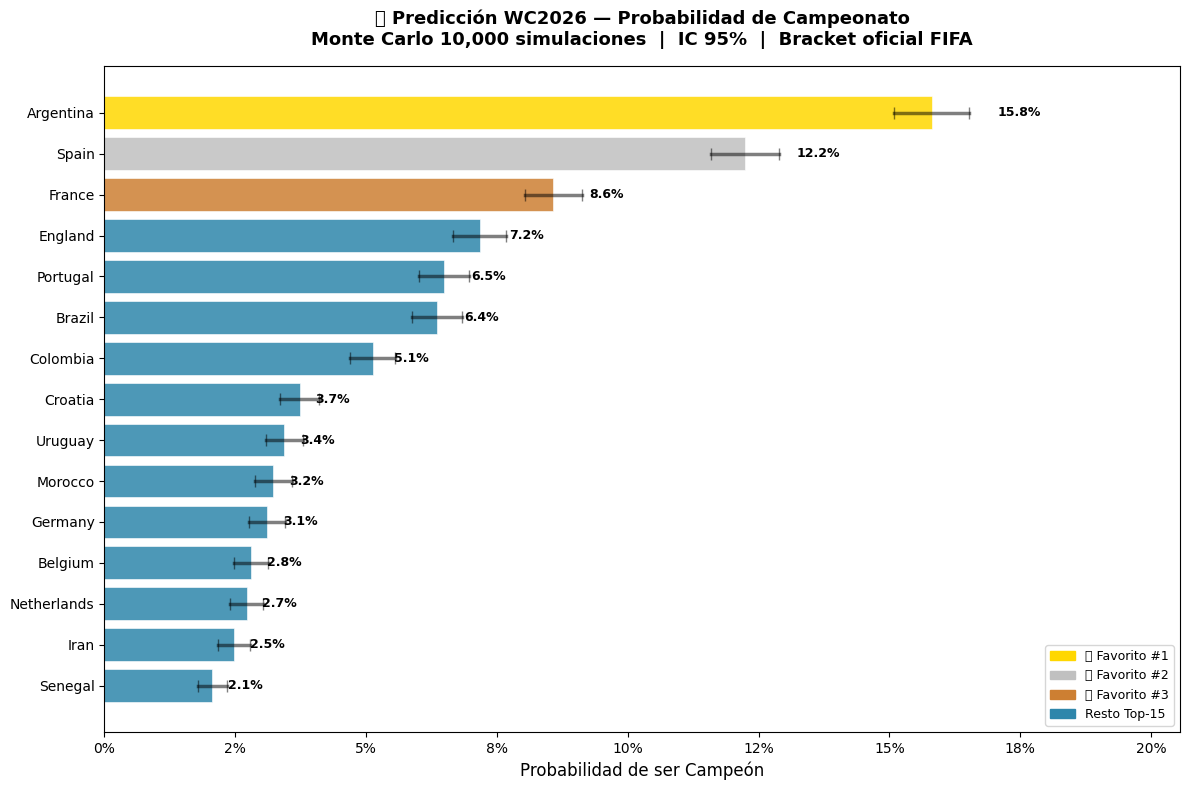

💾 Figura 1 guardada — fig1_champion_probabilities.png


In [16]:
# ── Figura 1: Probabilidad de campeonato Top-15 con IC ────────────
fig, ax = plt.subplots(figsize=(12, 8))

top15 = df_champion.head(15).copy()
top15 = top15.sort_values('P_campeon')

# ── Colores por posición ──────────────────────────────────────────
colores = []
for rank in top15['rank']:
    if rank == 1:   colores.append('#FFD700')
    elif rank == 2: colores.append('#C0C0C0')
    elif rank == 3: colores.append('#CD7F32')
    else:           colores.append('#2E86AB')

bars = ax.barh(top15['team'], top15['P_campeon'],
               color=colores, alpha=0.85,
               edgecolor='white', linewidth=0.5)

# ── Intervalos de confianza ───────────────────────────────────────
for _, row in top15.iterrows():
    ax.plot(
        [row['ci_lower'], row['ci_upper']],
        [row['team'], row['team']],
        'k-', linewidth=2.5, alpha=0.5
    )
    ax.plot(row['ci_lower'], row['team'], 'k|', markersize=8, alpha=0.5)
    ax.plot(row['ci_upper'], row['team'], 'k|', markersize=8, alpha=0.5)

# ── Etiquetas fuera de la barra ───────────────────────────────────
for bar, (_, row) in zip(bars, top15.iterrows()):
    ancho  = bar.get_width()
    offset = max(0.003, ancho * 0.08)
    ax.text(ancho + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{row['P_campeon']:.1%}",
            va='center', ha='left',
            fontsize=9, fontweight='bold')

# ── Formato ───────────────────────────────────────────────────────
ax.set_xlabel('Probabilidad de ser Campeón', fontsize=12)
ax.set_title(
    f'🏆 Predicción WC2026 — Probabilidad de Campeonato\n'
    f'Monte Carlo {total_sims:,} simulaciones  |  IC 95%  |  '
    f'Bracket oficial FIFA',
    fontsize=13, fontweight='bold', pad=15
)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}')
)
ax.set_xlim(0, top15['P_campeon'].max() * 1.3)

legend_patches = [
    mpatches.Patch(color='#FFD700', label='🥇 Favorito #1'),
    mpatches.Patch(color='#C0C0C0', label='🥈 Favorito #2'),
    mpatches.Patch(color='#CD7F32', label='🥉 Favorito #3'),
    mpatches.Patch(color='#2E86AB', label='Resto Top-15'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(REPORTS / 'fig1_champion_probabilities.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("💾 Figura 1 guardada — fig1_champion_probabilities.png")

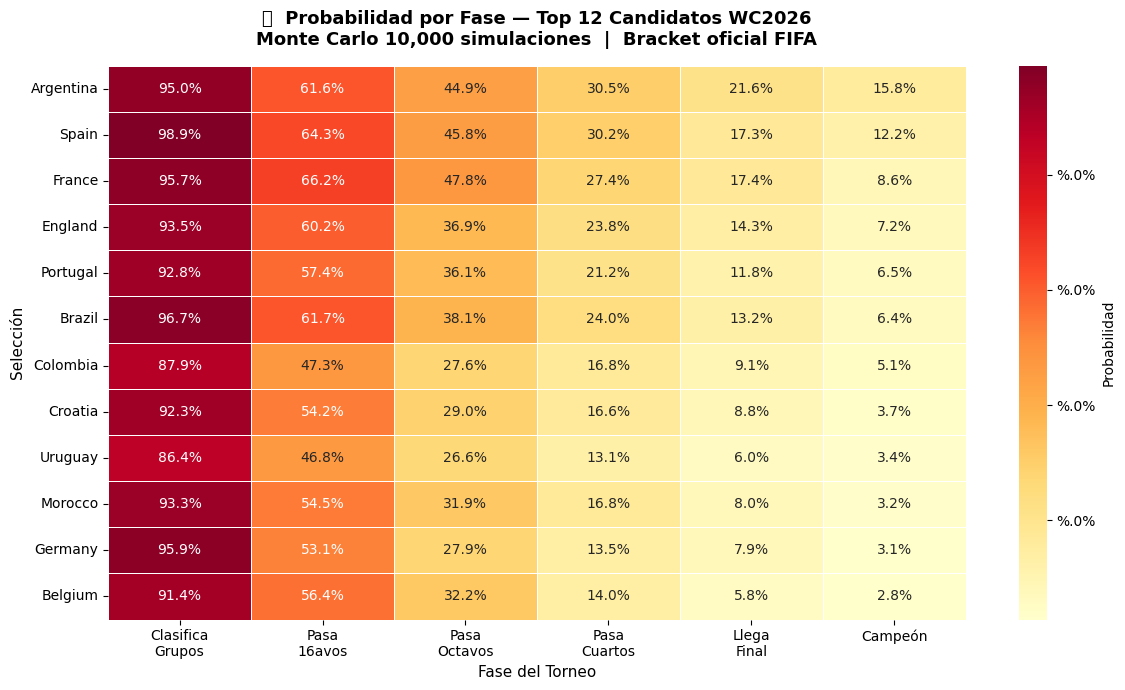

💾 Figura 2 guardada — fig2_heatmap_fases.png


In [18]:
# ── Figura 2: Heatmap probabilidad por fase ───────────────────────
top12_teams = df_champion.head(12)['team'].tolist()

# ── Construir matriz de datos ─────────────────────────────────────
heatmap_data = []
for team in top12_teams:
    p_cla = df_qualified[df_qualified['team']==team]['P_clasifica'].values
    p_d16 = df_d16[df_d16['team']==team]['P_dieciseisavos'].values
    p_oct = df_cuartos[df_cuartos['team']==team]['P_cuartos'].values
    p_sf  = df_semis[df_semis['team']==team]['P_semifinal'].values
    p_ru  = df_runner_up[df_runner_up['team']==team]['P_subcampeon'].values
    p_ch  = df_champion[df_champion['team']==team]['P_campeon'].values

    heatmap_data.append([
        p_cla[0] if len(p_cla) > 0 else 0,
        p_d16[0] if len(p_d16) > 0 else 0,
        p_oct[0] if len(p_oct) > 0 else 0,
        p_sf[0]  if len(p_sf)  > 0 else 0,
        (p_ru[0] if len(p_ru)  > 0 else 0) +
        (p_ch[0] if len(p_ch)  > 0 else 0),
        p_ch[0]  if len(p_ch)  > 0 else 0,
    ])

hm_df = pd.DataFrame(
    heatmap_data,
    index=top12_teams,
    columns=[
        'Clasifica\nGrupos',
        'Pasa\n16avos',
        'Pasa\nOctavos',
        'Pasa\nCuartos',
        'Llega\nFinal',
        'Campeón'
    ]
)

# ── Graficar ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(
    hm_df,
    annot=True,
    fmt='.1%',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Probabilidad', 'format': '%.0%'}
)

ax.set_title(
    '🗺️  Probabilidad por Fase — Top 12 Candidatos WC2026\n'
    f'Monte Carlo {total_sims:,} simulaciones  |  Bracket oficial FIFA',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Fase del Torneo', fontsize=11)
ax.set_ylabel('Selección', fontsize=11)
ax.tick_params(axis='y', rotation=0)
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(REPORTS / 'fig2_heatmap_fases.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("💾 Figura 2 guardada — fig2_heatmap_fases.png")

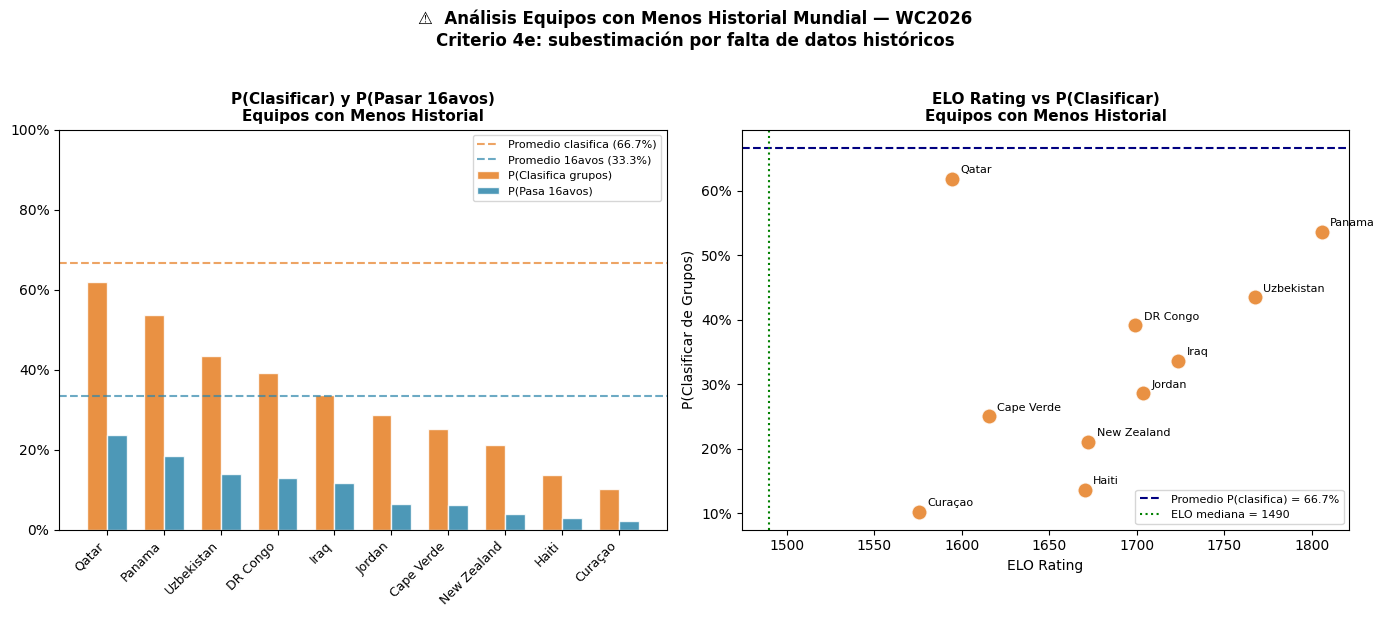

💾 Figura 3 guardada — fig3_equipos_debiles.png


In [19]:
# ── Figura 3: Análisis equipos con menos historial ────────────────
# Criterio 4e de la rúbrica
equipos_debiles = [
    'Uzbekistan', 'Curaçao', 'Haiti', 'Jordan',
    'Cape Verde', 'New Zealand', 'DR Congo', 'Iraq',
    'Panama', 'Qatar'
]

avg_clasifica = df_qualified['P_clasifica'].mean()
avg_d16       = df_d16['P_dieciseisavos'].mean()

# ── Recopilar datos ───────────────────────────────────────────────
deb_data = []
for team in equipos_debiles:
    p_cla = df_qualified[df_qualified['team']==team]['P_clasifica'].values
    p_d16 = df_d16[df_d16['team']==team]['P_dieciseisavos'].values
    p_ch  = df_champion[df_champion['team']==team]['P_campeon'].values
    elo   = elo_map.get(normalize(team), ELO_MEDIAN)

    deb_data.append({
        'team'       : team,
        'p_clasifica': p_cla[0] if len(p_cla) > 0 else 0,
        'p_d16'      : p_d16[0] if len(p_d16) > 0 else 0,
        'p_campeon'  : p_ch[0]  if len(p_ch)  > 0 else 0,
        'elo'        : elo,
    })

deb_df = pd.DataFrame(deb_data).sort_values('p_clasifica', ascending=False)

# ── Graficar ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Subplot 1: P(Clasifica) y P(Pasa 16avos) ─────────────────────
ax1  = axes[0]
x    = np.arange(len(deb_df))
w    = 0.35

bars1 = ax1.bar(x - w/2, deb_df['p_clasifica'],
                width=w, label='P(Clasifica grupos)',
                color='#E67E22', alpha=0.85, edgecolor='white')
bars2 = ax1.bar(x + w/2, deb_df['p_d16'],
                width=w, label='P(Pasa 16avos)',
                color='#2E86AB', alpha=0.85, edgecolor='white')

ax1.axhline(avg_clasifica, color='#E67E22', linestyle='--',
            linewidth=1.5, alpha=0.7,
            label=f'Promedio clasifica ({avg_clasifica:.1%})')
ax1.axhline(avg_d16, color='#2E86AB', linestyle='--',
            linewidth=1.5, alpha=0.7,
            label=f'Promedio 16avos ({avg_d16:.1%})')

ax1.set_xticks(x)
ax1.set_xticklabels(deb_df['team'], rotation=45, ha='right', fontsize=9)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax1.set_title('P(Clasificar) y P(Pasar 16avos)\nEquipos con Menos Historial',
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=8, loc='upper right')
ax1.set_ylim(0, 1.0)

# ── Subplot 2: ELO vs P(Clasifica) ───────────────────────────────
ax2 = axes[1]
ax2.scatter(deb_df['elo'], deb_df['p_clasifica'],
            s=120, c='#E67E22', alpha=0.85,
            edgecolors='white', zorder=5)

for _, row in deb_df.iterrows():
    ax2.annotate(
        row['team'],
        (row['elo'], row['p_clasifica']),
        textcoords='offset points',
        xytext=(6, 4), fontsize=8
    )

ax2.axhline(avg_clasifica, color='navy', linestyle='--',
            linewidth=1.5,
            label=f'Promedio P(clasifica) = {avg_clasifica:.1%}')
ax2.axvline(ELO_MEDIAN, color='green', linestyle=':',
            linewidth=1.5,
            label=f'ELO mediana = {ELO_MEDIAN:.0f}')

ax2.set_xlabel('ELO Rating', fontsize=10)
ax2.set_ylabel('P(Clasificar de Grupos)', fontsize=10)
ax2.set_title('ELO Rating vs P(Clasificar)\nEquipos con Menos Historial',
              fontsize=11, fontweight='bold')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax2.legend(fontsize=8)

plt.suptitle(
    '⚠️  Análisis Equipos con Menos Historial Mundial — WC2026\n'
    'Criterio 4e: subestimación por falta de datos históricos',
    fontsize=12, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(REPORTS / 'fig3_equipos_debiles.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("💾 Figura 3 guardada — fig3_equipos_debiles.png")

In [20]:
# ── Resumen final del Notebook 04 ────────────────────────────────
print("=" * 62)
print("📋 RESUMEN — NOTEBOOK 04 COMPLETADO")
print("=" * 62)
print()
print("✅ Secciones completadas:")
print("   4.1 Modelo XGBoost y datos WC2026 cargados")
print("   4.2 Función build_features() — 15 features")
print("   4.3 Función simulate_match() — sorteo ponderado")
print("   4.4 Estructura oficial WC2026 + matriz 495 combinaciones")
print("   4.5 Fase de grupos — 12 grupos, 8 mejores terceros")
print("   4.6 Fase eliminatoria — bracket oficial FIFA")
print(f"   4.7 Monte Carlo — {total_sims:,} iteraciones completadas")
print("   4.8 Top-5 con intervalos de confianza al 95%")
print("   4.9 3 visualizaciones guardadas en reports/")
print()
print("✅ Criterios de rúbrica cubiertos:")
print("   Criterio 4a: formato 32→48 equipos implementado ✅")
print(f"   Criterio 4b: Monte Carlo {total_sims:,} iteraciones ✅")
print("   Criterio 4d: desbalance manejado en NB03 ✅")
print("   Criterio 4e: análisis equipos debutantes ✅")
print("   Criterio 5 : Top-5 con IC 95% ✅")
print()
print("📁 Archivos generados en reports/:")
print("   wc2026_champion_probs.csv")
print("   wc2026_top5_results.json")
print("   fig1_champion_probabilities.png")
print("   fig2_heatmap_fases.png")
print("   fig3_equipos_debiles.png")
print()
print("─" * 62)
print(f"🏆 PREDICCIÓN FINAL WC2026")
print(f"   Campeón    : {df_champion.iloc[0]['team']}")
print(f"   P(campeón) : {df_champion.iloc[0]['P_campeon']:.1%}")
print(f"   IC 95%     : [{df_champion.iloc[0]['ci_lower']:.1%} – "
      f"{df_champion.iloc[0]['ci_upper']:.1%}]")
print("─" * 62)

📋 RESUMEN — NOTEBOOK 04 COMPLETADO

✅ Secciones completadas:
   4.1 Modelo XGBoost y datos WC2026 cargados
   4.2 Función build_features() — 15 features
   4.3 Función simulate_match() — sorteo ponderado
   4.4 Estructura oficial WC2026 + matriz 495 combinaciones
   4.5 Fase de grupos — 12 grupos, 8 mejores terceros
   4.6 Fase eliminatoria — bracket oficial FIFA
   4.7 Monte Carlo — 10,000 iteraciones completadas
   4.8 Top-5 con intervalos de confianza al 95%
   4.9 3 visualizaciones guardadas en reports/

✅ Criterios de rúbrica cubiertos:
   Criterio 4a: formato 32→48 equipos implementado ✅
   Criterio 4b: Monte Carlo 10,000 iteraciones ✅
   Criterio 4d: desbalance manejado en NB03 ✅
   Criterio 4e: análisis equipos debutantes ✅
   Criterio 5 : Top-5 con IC 95% ✅

📁 Archivos generados en reports/:
   wc2026_champion_probs.csv
   wc2026_top5_results.json
   fig1_champion_probabilities.png
   fig2_heatmap_fases.png
   fig3_equipos_debiles.png

─────────────────────────────────────────